# Sesión 3 — Momento–curvatura y rótulas plásticas

## Caso `mi_primer_analisis`: edificio de 1 piso y 1 vano

El objetivo es obtener, mediante discretización en fibras, la respuesta momento–curvatura de la columna `C1` y la viga `V1`, convertirla en leyes concentradas $M$–$\theta_p(P)$ y exportar el contrato que consumirán las sesiones siguientes.

Este es un ejemplo académico. Los criterios IO–LS–CP son provisionales y no constituyen una evaluación profesional.

## 1. Datos, unidades y modelo seccional

Las fuerzas se expresan en kgf, las longitudes en cm, los esfuerzos en kgf/cm² y las rotaciones en radianes. En cada valor de curvatura se busca la deformación axial que satisface el equilibrio de la fuerza normal impuesta.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

def buscar_raiz(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    for carpeta in (inicio, *inicio.parents):
        if (carpeta / "temario.md").is_file() and (carpeta / "PUSHOVER_PORTABLE").is_dir():
            return carpeta
    raise FileNotFoundError(
        "No se encontró la raíz del curso. En Colab, clona o monta primero el repositorio."
    )

RAIZ = buscar_raiz()
PORTABLE = RAIZ / "PUSHOVER_PORTABLE"
if str(PORTABLE) in sys.path:
    sys.path.remove(str(PORTABLE))
sys.path.insert(0, str(PORTABLE))

RUTA_MAESTRA = PORTABLE / "casos" / "mi_primer_analisis" / "entrada_maestra.json"
RUTA_GEOMETRIA = PORTABLE / "casos" / "mi_primer_analisis" / "geometria_secciones.json"
CASO_ID = "mi_primer_analisis"

from ejecutar_pushover import cargar_entrada_maestra
from sesion_03.casos_medrano import preparar_seccion
from sesion_03.modelo_seccion import crear_fibras, curva_momento_curvatura, resumir_curva
from sesion_03.modelo_rotula import propiedades_rotula
from sesion_03.biblioteca_rotulas import (
    generar_biblioteca_desde_entrada, guardar_contrato_sesion03,
    leer_contrato_sesion03,
)

entrada, ruta_geometria, cargas = cargar_entrada_maestra(RUTA_MAESTRA)
assert entrada["caso_id"] == CASO_ID
print("Caso:", entrada["caso_id"])
print("Pisos:", entrada["edificio"]["n_pisos"], "| vanos:", entrada["edificio"]["n_vanos_por_portico"])
print("Luz:", entrada["edificio"]["luz_cm"], "cm | altura:", entrada["edificio"]["altura_entrepiso_cm"], "cm")
print("Secciones:", ", ".join(entrada["secciones"]))

Caso: mi_primer_analisis
Pisos: 1 | vanos: 1
Luz: 500.0 cm | altura: 400.0 cm
Secciones: C1, V1


In [2]:
print(f"{'ID':<4} {'tipo':<9} {'b×h (cm)':<14} {'fc':>8} {'fy':>8} {'Lp':>7}")
for sid, sec in entrada["secciones"].items():
    print(f"{sid:<4} {sec['tipo']:<9} {sec['b_cm']:.0f}×{sec['h_cm']:.0f}"
          f"{sec['fc_kgf_cm2']:>11.1f} {sec['fy_kgf_cm2']:>8.1f} {sec['Lp_cm']:>7.1f}")

ID   tipo      b×h (cm)             fc       fy      Lp
C1   columna   30×30      210.0   4200.0    15.0
V1   viga      30×30      210.0   4200.0    15.0


## 2. Curvas momento–curvatura para $P=0$

Para cada sección se discretiza el concreto en franjas y se incorporan explícitamente las barras longitudinales. La curva termina al alcanzar el primer límite material o la curvatura máxima configurada. Si el evento final es `fin_phi`, $M_u$ representa el máximo calculado dentro del intervalo y no una capacidad última material demostrada. La rigidez secante a la primera fluencia se calcula como $EI_{sec}=M_y/\phi_y$.

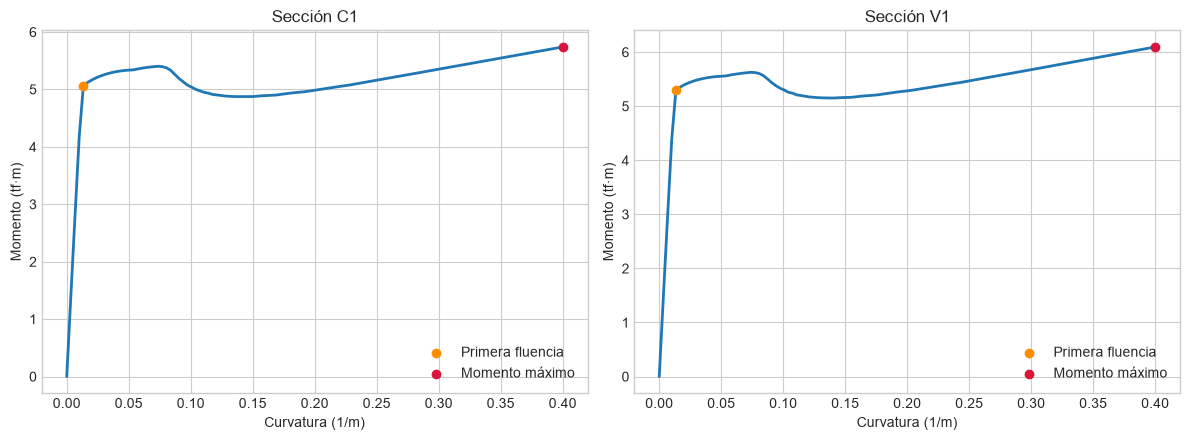

C1 My=5.064 tf·m Mu=5.739 tf·m evento final= fin_phi
V1 My=5.299 tf·m Mu=6.096 tf·m evento final= fin_phi


In [3]:
resultados_mc = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, sid in zip(axes, ("C1", "V1")):
    base = preparar_seccion(sid, RUTA_GEOMETRIA)
    fibras = crear_fibras(base["datos_seccion"])
    registros = curva_momento_curvatura(
        0.0, fibras, base["datos_seccion"], base["fl_ef"], base["rho_s"],
        base["eps_cu"], phi_max=entrada["biblioteca_rotulas"]["phi_max_1_cm"],
        n_pasos=entrada["biblioteca_rotulas"]["n_pasos"],
    )
    resumen = resumir_curva(registros, 0.0)
    rotula = propiedades_rotula(
        registros, resumen, base["datos_seccion"], Lp=base["Lp_cm"]
    )
    resultados_mc[sid] = {"base": base, "registros": registros, "resumen": resumen, "rotula": rotula}
    phi = np.array([r["phi"] for r in registros]) * 100.0
    momento = np.abs([r["M"] for r in registros]) / 1e5
    ax.plot(phi, momento, lw=2)
    ax.scatter(resumen["phi_y_1_cm"] * 100, resumen["My_kgf_cm"] / 1e5,
               color="darkorange", label="Primera fluencia", zorder=3)
    ax.scatter(resumen["phi_u_1_cm"] * 100, resumen["Mu_kgf_cm"] / 1e5,
               color="crimson", label="Momento máximo", zorder=3)
    ax.set(title=f"Sección {sid}", xlabel="Curvatura (1/m)", ylabel="Momento (tf·m)")
    ax.legend()
plt.tight_layout(); plt.show()

for sid, r in resultados_mc.items():
    q = r["resumen"]
    print(sid, f"My={q['My_kgf_cm']/1e5:.3f} tf·m",
          f"Mu={q['Mu_kgf_cm']/1e5:.3f} tf·m", "evento final=", q["evento_final"])

## 3. De la sección a la rótula concentrada

La rotación local se aproxima mediante $\theta=\phi L_p$. La rotación plástica se mide desde la fluencia: $\theta_p=(\phi-\phi_y)L_p$. Esta transformación conserva la trazabilidad entre respuesta de fibras y ley del extremo del elemento.

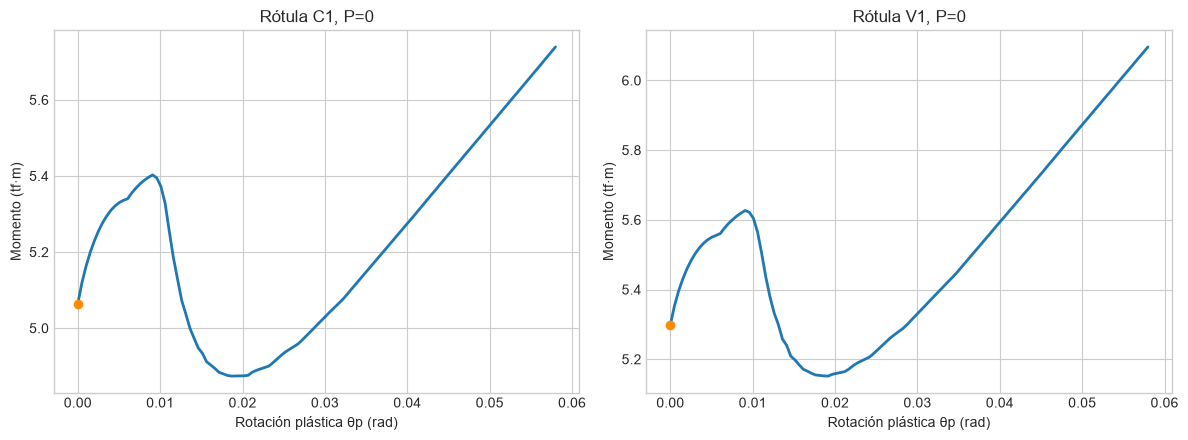

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, sid in zip(axes, ("C1", "V1")):
    rotula = resultados_mc[sid]["rotula"]
    theta = np.array(rotula["backbone_plastico"]["theta_p_rad"])
    momento = np.array(rotula["backbone_plastico"]["M_kgf_cm"]) / 1e5
    ax.plot(theta, momento, lw=2)
    ax.scatter(0, rotula["My_kgf_cm"] / 1e5, color="darkorange", zorder=3)
    ax.set(title=f"Rótula {sid}, P=0", xlabel="Rotación plástica θp (rad)", ylabel="Momento (tf·m)")
plt.tight_layout(); plt.show()

## 4. Biblioteca axial y contrato de la sesión 3

La columna se calcula para varias razones de carga axial y la viga para los niveles axiales definidos en el JSON. Se almacenan ramas positiva y negativa, porque la orientación del refuerzo puede cambiar la resistencia en cada sentido.

In [5]:
biblioteca, metadata = generar_biblioteca_desde_entrada(RUTA_GEOMETRIA)
for sid, datos in biblioteca.items():
    print(sid, "| estados +:", len(datos["positivo"]), "| estados -:", len(datos["negativo"]))
    for sentido in ("positivo", "negativo"):
        for estado in datos[sentido]:
            ley = estado["ley"]
            assert 0 < ley["My_kgf_cm"] <= ley["Mu_kgf_cm"]
            assert ley["theta_p_u_rad"] >= 0

SALIDA = RAIZ / "sesion_03" / "resultados_mi_primer_analisis"
RUTA_C03 = SALIDA / "contrato_sesion03.json"
guardar_contrato_sesion03(
    biblioteca, RUTA_C03,
    metadata_adicional={"caso_id": CASO_ID, "secciones": metadata},
)
contrato_s3 = leer_contrato_sesion03(RUTA_C03)
assert contrato_s3["schema_version"] == "3.5"
assert set(contrato_s3["biblioteca_rotulas"]) == {"C1", "V1"}
print("Contrato guardado:", RUTA_C03.relative_to(RAIZ))

C1 | estados +: 7 | estados -: 7
V1 | estados +: 3 | estados -: 3
Contrato guardado: sesion_03\resultados_mi_primer_analisis\contrato_sesion03.json


## 5. Interpretación y límites

La carga axial modifica rigidez, fluencia y capacidad de la columna; por eso la sesión 6 volverá a seleccionar su ley después del análisis gravitacional. Aún están pendientes comprobaciones frágiles independientes de cortante, anclajes y empalmes. Los límites IO–LS–CP del caso son provisionales para docencia.